# Hourly Accuracy Experiment (U06 First): With vs Without EHR-Constrained Transfer

This notebook is designed for operational forecasting (next few hours) with a strict development flow:

1. Start with **U06** and optimize/evaluate hourly forecast accuracy (`1h`, `3h`, `6h` ahead)
2. Then extend to portfolio with **adaptive per-building time splits**
3. Compare no-transfer baselines vs constrained EHR-based transfer

Data reused from existing project:
- Building/meter + KKP weather via `utils.building_data_loader`
- COP weather from `data/combined_weather_2022_2025.csv`
- EHR features from `data/ehr-building-data/ehr_building_summary.csv`


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from utils.building_data_loader import get_building_dataframe, load_campus_metadata

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 240)
warnings.filterwarnings('ignore')


## Configuration

In [2]:
WEATHER_FILE = PROJECT_ROOT / 'data' / 'combined_weather_2022_2025.csv'
EHR_FILE = PROJECT_ROOT / 'data' / 'ehr-building-data' / 'ehr_building_summary.csv'

DEV_BUILDING = 'U06'  # first-stage development target
HORIZONS = [1, 3, 6]  # hours ahead
SOURCES = ['kkp', 'cop']

T_BASE = 15.0
RIDGE_ALPHA = 2.0

# Adaptive split guardrails (hourly samples)
MIN_TRAIN_H = 24 * 30
MIN_VAL_H = 24 * 7
MIN_TEST_H = 24 * 7

# Transfer controls
TOP_K_DONORS = 3
MAX_DONOR_DIST = 3.5
ALPHA_GRID = np.linspace(0.0, 1.0, 11)

# Optional toggles
HEATING_SEASON_ONLY = False
RUN_PORTFOLIO = True

print(f'Weather: {WEATHER_FILE}')
print(f'EHR:     {EHR_FILE}')


Weather: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/combined_weather_2022_2025.csv
EHR:     /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/ehr-building-data/ehr_building_summary.csv


## Helpers

In [3]:
EHR_CODE_MAP = {
    'U02': 'U02 (+U02B)',
    'U02B': 'U02 (+U02B)',
    'U03': 'U03 (+U03B)',
    'U03B': 'U03 (+U03B)',
    'U06': 'U06 (+U06A)',
    'U06A': 'U06 (+U06A)',
}

SISTER_GROUPS = [
    {'U02', 'U02B'},
    {'U03', 'U03B'},
    {'U06', 'U06A'},
]


def map_to_ehr_code(building_code: str) -> str:
    return EHR_CODE_MAP.get(building_code, building_code)


def is_sister_pair(a: str, b: str) -> bool:
    for g in SISTER_GROUPS:
        if a in g and b in g:
            return True
    return False


def smape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100.0)


def peak_rmse(y_true, y_pred, q=0.9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    thr = np.quantile(y_true, q)
    mask = y_true >= thr
    if mask.sum() < 5:
        return np.nan
    return float(np.sqrt(np.mean((y_pred[mask] - y_true[mask]) ** 2)))


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred, 0, None)
    return {
        'r2': float(r2_score(y_true, y_pred)),
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'smape_pct': smape(y_true, y_pred),
        'peak_rmse': peak_rmse(y_true, y_pred, q=0.9),
    }


def weighted_theta_average(theta_list, dist_list):
    w = np.exp(-np.asarray(dist_list, dtype=float))
    if np.allclose(w.sum(), 0):
        w = np.ones_like(w)
    w = w / w.sum()
    return np.average(np.vstack(theta_list), axis=0, weights=w)


In [4]:
def load_building_hourly_common(building_code, weather_df, overview_df, building_codes_df, t_base=T_BASE):
    # Load one building and produce common hourly target + KKP/COP weather features.
    df_kkp = get_building_dataframe(
        building_code,
        overview_df=overview_df,
        building_codes_df=building_codes_df,
        include_weather=True,
        verbose=False,
    )
    df_heat = get_building_dataframe(
        building_code,
        overview_df=overview_df,
        building_codes_df=building_codes_df,
        include_weather=False,
        verbose=False,
    )

    heat_cols = [c for c in df_heat.columns if 'measurement_delta_mwh' in c]
    if not heat_cols:
        raise ValueError('No heat meter columns found')

    cop_cols = [c for c in weather_df.columns if c.startswith('COP_')]
    df_cop = df_heat.merge(weather_df[cop_cols], left_on='datetime', right_index=True, how='left')

    df_heat['Phi_kWh'] = df_heat[heat_cols].sum(axis=1) * 1e3
    base = df_heat[['datetime', 'Phi_kWh']].copy()

    kkp_w = df_kkp[['datetime', 'air_temp_c', 'wind_speed_ms']].rename(
        columns={'air_temp_c': 'kkp_temp', 'wind_speed_ms': 'kkp_wind'}
    )
    cop_w = df_cop[['datetime', 'COP_temp_c', 'COP_wind_speed_ms', 'COP_ssrd_W_per_m2']].rename(
        columns={
            'COP_temp_c': 'cop_temp',
            'COP_wind_speed_ms': 'cop_wind',
            'COP_ssrd_W_per_m2': 'cop_solar',
        }
    )

    d = base.merge(kkp_w, on='datetime', how='left').merge(cop_w, on='datetime', how='left')
    d = d.sort_values('datetime').drop_duplicates(subset=['datetime'], keep='last').reset_index(drop=True)
    d = d.dropna(subset=['kkp_temp', 'kkp_wind', 'cop_temp', 'cop_wind']).copy()

    if HEATING_SEASON_ONLY:
        d = d[d['datetime'].dt.month.isin([1, 2, 3, 4, 10, 11, 12])].copy()

    d['kkp_dT'] = t_base - d['kkp_temp']
    d['cop_dT'] = t_base - d['cop_temp']

    d['Phi_lag1'] = d['Phi_kWh'].shift(1)
    d['Phi_lag2'] = d['Phi_kWh'].shift(2)
    d['Phi_lag24'] = d['Phi_kWh'].shift(24)

    d['hour'] = d['datetime'].dt.hour
    d['dow'] = d['datetime'].dt.dayofweek
    d['month'] = d['datetime'].dt.month
    d['is_weekend'] = (d['dow'] >= 5).astype(int)

    d['hour_sin'] = np.sin(2 * np.pi * d['hour'] / 24)
    d['hour_cos'] = np.cos(2 * np.pi * d['hour'] / 24)
    d['dow_sin'] = np.sin(2 * np.pi * d['dow'] / 7)
    d['dow_cos'] = np.cos(2 * np.pi * d['dow'] / 7)
    d['month_sin'] = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos'] = np.cos(2 * np.pi * d['month'] / 12)

    return d


def make_horizon_frame(hourly_df, horizon_h, source):
    if source not in ('kkp', 'cop'):
        raise ValueError('source must be kkp or cop')

    d = hourly_df.copy().sort_values('datetime').reset_index(drop=True)
    d['y_kwh'] = d['Phi_kWh'].shift(-horizon_h)

    feat = [
        f'{source}_dT',
        f'{source}_wind',
        'Phi_lag1',
        'Phi_lag2',
        'Phi_lag24',
        'hour_sin',
        'hour_cos',
        'dow_sin',
        'dow_cos',
        'month_sin',
        'month_cos',
        'is_weekend',
    ]

    keep_cols = ['datetime', 'Phi_kWh', 'y_kwh'] + feat
    d = d[keep_cols].dropna().copy().reset_index(drop=True)
    return d, feat


def adaptive_time_split(df):
    d = df.sort_values('datetime').reset_index(drop=True)
    n = len(d)

    test_n = int(round(0.2 * n))
    val_n = int(round(0.1 * n))

    test_n = min(max(test_n, MIN_TEST_H), 24 * 120)
    val_n = min(max(val_n, MIN_VAL_H), 24 * 60)

    if n - test_n - val_n < MIN_TRAIN_H:
        remaining = n - MIN_TRAIN_H
        if remaining < MIN_VAL_H + MIN_TEST_H:
            return None, None, None
        test_n = max(MIN_TEST_H, int(remaining * (2 / 3)))
        val_n = max(MIN_VAL_H, remaining - test_n)

    train_end = n - (val_n + test_n)
    val_end = n - test_n

    train = d.iloc[:train_end].copy()
    val = d.iloc[train_end:val_end].copy()
    test = d.iloc[val_end:].copy()

    if len(train) < MIN_TRAIN_H or len(val) < MIN_VAL_H or len(test) < MIN_TEST_H:
        return None, None, None

    return train, val, test


In [5]:
def fit_local_models(train, val, test, feat_cols, area_scale=1.0):
    out = []

    y_train = train['y_kwh'] / area_scale
    y_test = test['y_kwh']

    X_train = train[feat_cols]
    X_test = test[feat_cols]

    yhat_p = test['Phi_kWh'].to_numpy(dtype=float)
    m = compute_metrics(y_test.to_numpy(dtype=float), yhat_p)
    out.append({'model': 'persistence', **m})

    ols = LinearRegression().fit(X_train, y_train)
    yhat_ols = np.clip(ols.predict(X_test) * area_scale, 0, None)
    m = compute_metrics(y_test.to_numpy(dtype=float), yhat_ols)
    out.append({'model': 'local_ols', **m, 'theta': np.concatenate(([ols.intercept_], ols.coef_))})

    ridge = Ridge(alpha=RIDGE_ALPHA).fit(X_train, y_train)
    yhat_ridge = np.clip(ridge.predict(X_test) * area_scale, 0, None)
    m = compute_metrics(y_test.to_numpy(dtype=float), yhat_ridge)
    out.append({'model': 'local_ridge', **m})

    return out


def fit_donor_ols(train_df, feat_cols, scale):
    y = train_df['y_kwh'] / scale
    X = train_df[feat_cols]
    m = LinearRegression().fit(X, y)
    return float(m.intercept_), np.asarray(m.coef_, dtype=float)


def resolve_transfer_scale(building_code, volume_map, area_map, area_fallback=1.0):
    """Prefer kWh/m3 (volume), fallback to kWh/m2 (area), else unit scale."""
    v = volume_map.get(building_code)
    if v is not None and np.isfinite(v) and v > 0:
        return float(v), 'volume_m3'

    a = area_map.get(building_code, area_fallback)
    if a is not None and np.isfinite(a) and a > 0:
        return float(a), 'area_m2'

    return 1.0, 'unit'


def run_constrained_transfer(target_building, source, horizon, feat_cols, train_t, val_t, test_t, area_t,
                             hourly_by_building, ehr_dist_df, area_map, volume_map):
    target_scale, target_scale_type = resolve_transfer_scale(target_building, volume_map, area_map, area_fallback=area_t)

    # Local model in normalized target space (prefer kWh/m3).
    local_model = LinearRegression().fit(train_t[feat_cols], train_t['y_kwh'] / target_scale)
    b_loc = float(local_model.intercept_)
    w_loc = np.asarray(local_model.coef_, dtype=float)

    if target_building not in ehr_dist_df.index:
        return None

    donor_candidates = []
    distances = ehr_dist_df.loc[target_building].sort_values()
    for donor, dist in distances.items():
        if donor == target_building:
            continue
        if is_sister_pair(target_building, donor):
            continue
        if dist > MAX_DONOR_DIST:
            continue
        if donor not in hourly_by_building:
            continue

        d_h = hourly_by_building[donor]
        d_frame, d_feats = make_horizon_frame(d_h, horizon_h=horizon, source=source)
        if d_feats != feat_cols:
            continue
        tr_d, va_d, te_d = adaptive_time_split(d_frame)
        if tr_d is None:
            continue

        donor_scale, donor_scale_type = resolve_transfer_scale(donor, volume_map, area_map)

        try:
            b_d, w_d = fit_donor_ols(tr_d, feat_cols, scale=donor_scale)
            donor_candidates.append({
                'donor': donor,
                'dist': float(dist),
                'b': b_d,
                'w': w_d,
                'scale_type': donor_scale_type,
            })
        except Exception:
            continue

        if len(donor_candidates) >= TOP_K_DONORS:
            break

    if len(donor_candidates) == 0:
        return None

    donor_ws = [d['w'] for d in donor_candidates]
    donor_dist = [d['dist'] for d in donor_candidates]
    w_d_avg = weighted_theta_average(donor_ws, donor_dist)

    weather_idx = [0, 1]  # dT and wind only

    X_val = val_t[feat_cols].to_numpy(dtype=float)
    y_val = val_t['y_kwh'].to_numpy(dtype=float)
    X_test = test_t[feat_cols].to_numpy(dtype=float)
    y_test = test_t['y_kwh'].to_numpy(dtype=float)

    best = None
    for alpha in ALPHA_GRID:
        w_mix = w_loc.copy()
        for j in weather_idx:
            w_mix[j] = alpha * w_loc[j] + (1 - alpha) * w_d_avg[j]

        # Convert back from normalized units to kWh using target scale.
        pred_val = np.clip((b_loc + X_val @ w_mix) * target_scale, 0, None)
        rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))

        if best is None or rmse_val < best['rmse_val']:
            best = {'alpha': float(alpha), 'w_mix': w_mix, 'rmse_val': float(rmse_val)}

    pred_test = np.clip((b_loc + X_test @ best['w_mix']) * target_scale, 0, None)
    met = compute_metrics(y_test, pred_test)

    return {
        'model': 'transfer_weather_blend',
        'alpha_weather_local': best['alpha'],
        'n_donors': len(donor_candidates),
        'donors': [d['donor'] for d in donor_candidates],
        'donor_distances': [round(d['dist'], 3) for d in donor_candidates],
        'transfer_target_scale': target_scale,
        'transfer_target_scale_type': target_scale_type,
        'donor_scale_types': sorted(list({d['scale_type'] for d in donor_candidates})),
        **met,
    }


## Load Inputs

In [6]:
overview_df, building_codes_df = load_campus_metadata()
weather_df = pd.read_csv(WEATHER_FILE, parse_dates=['datetime'], index_col='datetime')
ehr_df = pd.read_csv(EHR_FILE)

all_buildings = sorted([b for b in overview_df['Hoone'].dropna().unique().tolist() if b != 'NRG'])
print(f'Buildings from metadata: {len(all_buildings)}')
print(all_buildings)


Buildings from metadata: 17
['GEO', 'ICO', 'LIB', 'SOC', 'STU', 'U01', 'U01U02', 'U02', 'U02B', 'U03', 'U03B', 'U04', 'U04B', 'U05', 'U05B', 'U06', 'U06A']


## Build Hourly Base Frames for All Buildings

In [7]:
hourly_by_building = {}
load_errors = {}

for b in all_buildings:
    try:
        d = load_building_hourly_common(b, weather_df, overview_df, building_codes_df)
        if len(d) < (MIN_TRAIN_H + MIN_VAL_H + MIN_TEST_H + max(HORIZONS) + 24):
            load_errors[b] = f'too few usable rows ({len(d)})'
            continue
        hourly_by_building[b] = d
    except Exception as e:
        load_errors[b] = str(e)

print(f'Loaded hourly frames: {len(hourly_by_building)}')
print(f'Skipped: {len(load_errors)}')
if load_errors:
    display(pd.Series(load_errors).sort_index())


Loaded hourly frames: 17
Skipped: 0


## Build EHR Similarity and Area Scale

In [8]:
ehr_num = [
    'first_use_year', 'gross_volume_m3', 'footprint_area_m2', 'heated_area_m2',
    'max_floors', 'height_m', 'volume_per_heated_area', 'compactness_ratio',
    'orientation_azimuth_deg', 'orientation_edge_share',
]

avail = [c for c in ehr_num if c in ehr_df.columns]

rows = []
area_map = {}
volume_map = {}
for b in hourly_by_building.keys():
    ecode = map_to_ehr_code(b)
    r = ehr_df[ehr_df['campus_code'] == ecode]
    if r.empty:
        continue
    rr = r.iloc[0]
    item = {'building': b, 'ehr_code': ecode}
    for c in avail:
        item[c] = rr.get(c)
    rows.append(item)

    area = pd.to_numeric(rr.get('heated_area_m2'), errors='coerce')
    if pd.isna(area) or area <= 0:
        area = 1.0
    area_map[b] = float(area)

    vol = pd.to_numeric(rr.get('gross_volume_m3'), errors='coerce')
    if pd.notna(vol) and vol > 0:
        volume_map[b] = float(vol)

# Add fallback volume scales for buildings missing EHR volume.
for b in hourly_by_building.keys():
    if b not in volume_map:
        # fallback hierarchy: area map then unit scale
        volume_map[b] = float(area_map.get(b, 1.0))

ehr_feat = pd.DataFrame(rows)
for c in avail:
    ehr_feat[c] = pd.to_numeric(ehr_feat[c], errors='coerce').replace([np.inf, -np.inf], np.nan)

X = ehr_feat[avail].copy()
X = X.fillna(X.median(numeric_only=True))
X = (X - X.mean()) / X.std(ddof=0).replace(0, 1)

mat = X.to_numpy(dtype=float)
code_list = ehr_feat['building'].tolist()
dist = np.sqrt(((mat[:, None, :] - mat[None, :, :]) ** 2).sum(axis=2))
ehr_dist_df = pd.DataFrame(dist, index=code_list, columns=code_list)

print(f'Buildings with EHR vectors: {len(code_list)} / {len(hourly_by_building)}')
print('Sample area scaling (local models):')
display(pd.Series(area_map).sort_index().head(10))
print('Sample volume scaling (transfer models):')
display(pd.Series(volume_map).sort_index().head(10))


Buildings with EHR vectors: 16 / 17
Sample area scaling (local models):


GEO       898.2
ICO         1.0
LIB     10647.0
SOC     10360.0
STU         1.0
U01      4088.7
U02     24136.0
U02B    24136.0
U03      5908.0
U03B     5908.0
dtype: float64

Sample volume scaling (transfer models):


GEO        3875.0
ICO       18237.2
LIB       43567.0
SOC       45882.4
STU          39.0
U01       21780.0
U01U02        1.0
U02       24136.0
U02B      24136.0
U03       30456.0
dtype: float64

## Stage 1: U06 Development (Hourly Accuracy)

Run detailed `with/without transfer` comparison for `U06` first.


In [9]:
u06_results = []

if DEV_BUILDING not in hourly_by_building:
    raise RuntimeError(f'{DEV_BUILDING} not available in hourly frames')

base_u06 = hourly_by_building[DEV_BUILDING]
area_u06 = area_map.get(DEV_BUILDING, 1.0)

for h in HORIZONS:
    for src in SOURCES:
        frame, feats = make_horizon_frame(base_u06, horizon_h=h, source=src)
        tr, va, te = adaptive_time_split(frame)
        if tr is None:
            u06_results.append({'building': DEV_BUILDING, 'horizon_h': h, 'source': src, 'model': 'split_failed'})
            continue

        local_rows = fit_local_models(tr, va, te, feats, area_scale=area_u06)
        for r in local_rows:
            u06_results.append({'building': DEV_BUILDING, 'horizon_h': h, 'source': src, **r})

        trf = run_constrained_transfer(
            target_building=DEV_BUILDING,
            source=src,
            horizon=h,
            feat_cols=feats,
            train_t=tr,
            val_t=va,
            test_t=te,
            area_t=area_u06,
            hourly_by_building=hourly_by_building,
            ehr_dist_df=ehr_dist_df,
            area_map=area_map,
            volume_map=volume_map,
        )
        if trf is not None:
            u06_results.append({'building': DEV_BUILDING, 'horizon_h': h, 'source': src, **trf})

u06_df = pd.DataFrame(u06_results)
print('U06 detailed results:')
display(u06_df.sort_values(['horizon_h', 'source', 'model']))


U06 detailed results:


,building,horizon_h,source,model,r2,rmse,mae,smape_pct,peak_rmse,theta,alpha_weather_local,n_donors,donors,donor_distances,transfer_target_scale,transfer_target_scale_type,donor_scale_types
5,U06,1,cop,local_ols,-0.135058,176.929848,39.822429,90.242505,498.756568,"[0.001088264315144383, 0.0003096096771828083, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,U06,1,cop,local_ridge,-0.135056,176.929696,39.819282,90.239709,498.756772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,U06,1,cop,persistence,-0.858634,226.406519,14.261458,20.912037,501.871284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,U06,1,cop,transfer_weather_blend,-0.135058,176.929848,39.822429,90.242505,498.756568,NaN,1.0,3.0,"[SOC, U03, U03B]","[2.819, 2.92, 2.92]",61946.0,volume_m3,[volume_m3]
1,U06,1,kkp,local_ols,-0.138108,177.167384,40.639690,90.476638,498.859927,"[0.000971659765024847, 0.0003102233981097511, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,U06,1,kkp,local_ridge,-0.138105,177.167134,40.636348,90.474350,498.860081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,U06,1,kkp,persistence,-0.858634,226.406519,14.261458,20.912037,501.871284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,U06,1,kkp,transfer_weather_blend,-0.123128,175.997566,35.670808,87.322610,498.960478,NaN,0.0,3.0,"[SOC, U03, U03B]","[2.819, 2.92, 2.92]",61946.0,volume_m3,[volume_m3]
13,U06,3,cop,local_ols,-0.142142,177.481108,45.410246,93.895621,499.738456,"[0.0013149694376280371, 0.0003451059014949408,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,U06,3,cop,local_ridge,-0.142137,177.480681,45.406787,93.892558,499.738637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
if not u06_df.empty:
    cmp_cols = ['r2', 'rmse', 'mae', 'smape_pct', 'peak_rmse']
    for metric in cmp_cols:
        t = u06_df.pivot_table(index=['horizon_h', 'source'], columns='model', values=metric, aggfunc='first')
        print(f'\n=== U06 {metric} ===')
        display(t)



=== U06 r2 ===


model             local_ols  local_ridge  persistence  transfer_weather_blend
horizon_h source                                                             
1         cop     -0.135058    -0.135056    -0.858634               -0.135058
          kkp     -0.138108    -0.138105    -0.858634               -0.123128
3         cop     -0.142142    -0.142137    -0.861648               -0.140711
          kkp     -0.146367    -0.146361    -0.861648               -0.146367
6         cop     -0.151234    -0.151217    -0.881825               -0.151234
          kkp     -0.157677    -0.157659    -0.881825               -0.157677


=== U06 rmse ===


model              local_ols  local_ridge  persistence  transfer_weather_blend
horizon_h source                                                              
1         cop     176.929848   176.929696   226.406519              176.929848
          kkp     177.167384   177.167134   226.406519              175.997566
3         cop     177.481108   177.480681   226.590051              177.369844
          kkp     177.809080   177.808563   226.590051              177.809080
6         cop     178.186107   178.184798   227.814659              178.186107
          kkp     178.684005   178.682621   227.814659              178.684005


=== U06 mae ===


model             local_ols  local_ridge  persistence  transfer_weather_blend
horizon_h source                                                             
1         cop     39.822429    39.819282    14.261458               39.822429
          kkp     40.639690    40.636348    14.261458               35.670808
3         cop     45.410246    45.406787    16.886979               45.017346
          kkp     46.449963    46.446375    16.886979               46.449963
6         cop     56.192071    56.186976    21.030556               56.192071
          kkp     57.139584    57.134329    21.030556               57.139584


=== U06 smape_pct ===


model              local_ols  local_ridge  persistence  transfer_weather_blend
horizon_h source                                                              
1         cop      90.242505    90.239709    20.912037               90.242505
          kkp      90.476638    90.474350    20.912037               87.322610
3         cop      93.895621    93.892558    29.514290               93.669980
          kkp      94.439703    94.436576    29.514290               94.439703
6         cop     100.560922   100.557219    39.764300              100.560922
          kkp     100.581484   100.579604    39.764300              100.581484


=== U06 peak_rmse ===


model              local_ols  local_ridge  persistence  transfer_weather_blend
horizon_h source                                                              
1         cop     498.756568   498.756772   501.871284              498.756568
          kkp     498.859927   498.860081   501.871284              498.960478
3         cop     499.738456   499.738637   501.826216              499.739175
          kkp     500.020813   500.020933   501.826216              500.020813
6         cop     500.401596   500.401585   505.239640              500.401596
          kkp     500.627696   500.627667   505.239640              500.627696

## Stage 2: Portfolio Extension (Adaptive per Building)

After U06, apply the same protocol across other buildings.


In [11]:
portfolio_rows = []

if RUN_PORTFOLIO:
    for b, hourly in hourly_by_building.items():
        area_b = area_map.get(b, 1.0)

        for h in HORIZONS:
            for src in SOURCES:
                frame, feats = make_horizon_frame(hourly, horizon_h=h, source=src)
                tr, va, te = adaptive_time_split(frame)
                if tr is None:
                    portfolio_rows.append({'building': b, 'horizon_h': h, 'source': src, 'model': 'split_failed'})
                    continue

                local_rows = fit_local_models(tr, va, te, feats, area_scale=area_b)
                for r in local_rows:
                    portfolio_rows.append({'building': b, 'horizon_h': h, 'source': src, **r})

                trf = run_constrained_transfer(
                    target_building=b,
                    source=src,
                    horizon=h,
                    feat_cols=feats,
                    train_t=tr,
                    val_t=va,
                    test_t=te,
                    area_t=area_b,
                    hourly_by_building=hourly_by_building,
                    ehr_dist_df=ehr_dist_df,
                    area_map=area_map,
                    volume_map=volume_map,
                )
                if trf is not None:
                    portfolio_rows.append({'building': b, 'horizon_h': h, 'source': src, **trf})

portfolio_df = pd.DataFrame(portfolio_rows)
print(f'Portfolio result rows: {len(portfolio_df)}')
portfolio_df.head()


Portfolio result rows: 384


,building,horizon_h,source,model,r2,rmse,mae,smape_pct,peak_rmse,theta,alpha_weather_local,n_donors,donors,donor_distances,transfer_target_scale,transfer_target_scale_type,donor_scale_types
0,GEO,1,kkp,persistence,0.861462,5.637962,3.226839,36.799169,11.297577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GEO,1,kkp,local_ols,0.764745,7.346952,4.306168,70.073905,16.856207,"[0.0004805236855023008, 0.00012115234786888498...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GEO,1,kkp,local_ridge,0.764743,7.346983,4.306145,70.077730,16.856301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GEO,1,cop,persistence,0.861462,5.637962,3.226839,36.799169,11.297577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GEO,1,cop,local_ols,0.764221,7.355124,4.310634,70.084640,16.876003,"[0.0005011864691167479, 0.00012189975268336542...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
if not portfolio_df.empty:
    valid = portfolio_df[~portfolio_df['model'].isin(['split_failed'])].copy()

    print('Mean metrics by horizon/source/model:')
    mean_tbl = valid.groupby(['horizon_h', 'source', 'model'])[['r2', 'rmse', 'mae', 'smape_pct', 'peak_rmse']].mean().round(4)
    display(mean_tbl)

    base = valid[valid['model'] == 'local_ols'][['building', 'horizon_h', 'source', 'r2', 'rmse', 'mae']].rename(
        columns={'r2': 'r2_base', 'rmse': 'rmse_base', 'mae': 'mae_base'}
    )

    trf_cols = ['building', 'horizon_h', 'source', 'r2', 'rmse', 'mae', 'alpha_weather_local', 'n_donors']
    for extra in ['transfer_target_scale', 'transfer_target_scale_type', 'donor_scale_types']:
        if extra in valid.columns:
            trf_cols.append(extra)

    trf = valid[valid['model'] == 'transfer_weather_blend'][trf_cols].rename(
        columns={'r2': 'r2_transfer', 'rmse': 'rmse_transfer', 'mae': 'mae_transfer'}
    )

    gain = base.merge(trf, on=['building', 'horizon_h', 'source'], how='inner')
    gain['delta_r2'] = gain['r2_transfer'] - gain['r2_base']
    gain['delta_rmse'] = gain['rmse_transfer'] - gain['rmse_base']
    gain['delta_mae'] = gain['mae_transfer'] - gain['mae_base']

    print('Transfer vs local_ols (negative delta_rmse is better):')
    display(gain.sort_values('delta_r2', ascending=False))

    print('Mean transfer deltas by horizon/source:')
    display(gain.groupby(['horizon_h', 'source'])[['delta_r2', 'delta_rmse', 'delta_mae']].mean().round(4))


Mean metrics by horizon/source/model:


r2      rmse      mae  smape_pct  peak_rmse
horizon_h source model                                                                  
1         cop    local_ols               0.0957  160.5900  25.5858    91.6272   443.6325
                 local_ridge             0.0957  160.5904  25.5844    91.6171   443.6327
                 persistence            -0.4009  203.0648  16.0473    31.5756   451.8243
                 transfer_weather_blend -0.0978  199.6256  32.4568   100.7647   555.1862
          kkp    local_ols               0.0948  160.5814  25.7619    91.4284   443.5665
                 local_ridge             0.0948  160.5818  25.7605    91.4307   443.5667
                 persistence            -0.4009  203.0648  16.0473    31.5756   451.8243
                 transfer_weather_blend  0.0034  198.1112  28.8242    97.9241   555.4825
3         cop    local_ols               0.0711  159.1523  28.6973    95.6255   446.8447
                 local_ridge             0.0711  159.1526  28.6958    95.6236   446.8450
                 persistence            -0.4850  206.1148  20.4601    45.4723   455.3332
                 transfer_weather_blend -0.1785  198.2264  36.2438   104.8320   558.2461
          kkp    local_ols               0.0699  159.1242  28.9032    95.4518   446.7202
                 local_ridge             0.0699  159.1244  28.9017    95.4501   446.7204
                 persistence            -0.4850  206.1148  20.4601    45.4723   455.3332
                 transfer_weather_blend -0.0159  196.1440  32.4452   101.3257   558.3972
6         cop    local_ols               0.0362  157.8229  33.0915    99.9353   446.6790
                 local_ridge             0.0362  157.8227  33.0893    99.9332   446.6790
                 persistence            -0.5629  207.4733  24.2347    56.7100   458.1747
                 transfer_weather_blend -0.2068  195.8534  40.2422   108.1221   555.9199
          kkp    local_ols               0.0331  157.8846  33.3429    99.6893   446.6054
                 local_ridge             0.0331  157.8844  33.3408    99.6872   446.6055
                 persistence            -0.5629  207.4733  24.2347    56.7100   458.1747
                 transfer_weather_blend -0.0301  193.9584  37.0251   104.4297   555.6763

Transfer vs local_ols (negative delta_rmse is better):


,building,horizon_h,source,r2_base,rmse_base,mae_base,r2_transfer,rmse_transfer,mae_transfer,alpha_weather_local,n_donors,transfer_target_scale,transfer_target_scale_type,donor_scale_types,delta_r2,delta_rmse,delta_mae
66,U06,1,kkp,-0.138108,177.167384,40.639690,-0.123128,175.997566,35.670808,0.0,3.0,61946.0,volume_m3,[volume_m3],1.498000e-02,-1.169818e+00,-4.968882
42,U04,1,kkp,-0.102141,406.806904,64.084531,-0.096327,405.732407,57.324134,0.7,3.0,24521.0,volume_m3,[volume_m3],5.814468e-03,-1.074497e+00,-6.760397
44,U04,3,kkp,-0.104141,407.175887,66.587481,-0.099999,406.411377,62.141593,0.8,3.0,24521.0,volume_m3,[volume_m3],4.142360e-03,-7.645100e-01,-4.445888
69,U06,3,cop,-0.142142,177.481108,45.410246,-0.140711,177.369844,45.017346,0.9,3.0,61946.0,volume_m3,[volume_m3],1.431582e-03,-1.112639e-01,-0.392900
68,U06,3,kkp,-0.146367,177.809080,46.449963,-0.146367,177.809080,46.449963,1.0,3.0,61946.0,volume_m3,[volume_m3],6.661338e-16,-2.842171e-14,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,U05B,1,cop,-0.175915,21.149080,6.786345,-0.845172,26.492438,15.576662,0.4,3.0,11539.0,volume_m3,[volume_m3],-6.692569e-01,5.343359e+00,8.790317
75,U06A,3,cop,-0.198967,24.592842,8.197457,-1.043642,32.107576,19.562445,0.5,3.0,61946.0,volume_m3,[volume_m3],-8.446750e-01,7.514734e+00,11.364988
65,U05B,6,cop,-0.385914,22.959990,11.603941,-1.251824,29.266496,19.902792,0.5,3.0,11539.0,volume_m3,[volume_m3],-8.659095e-01,6.306505e+00,8.298851
63,U05B,3,cop,-0.250010,21.805206,8.863573,-1.301077,29.584832,19.618710,0.3,3.0,11539.0,volume_m3,[volume_m3],-1.051067e+00,7.779626e+00,10.755137


Mean transfer deltas by horizon/source:


delta_r2  delta_rmse  delta_mae
horizon_h source                                 
1         cop      -0.1234      1.6877     4.0162
          kkp      -0.0208      0.1688     0.1486
3         cop      -0.1828      2.2616     4.3008
          kkp      -0.0183      0.1888     0.2262
6         cop      -0.1815      2.0678     3.4531
          kkp      -0.0010      0.0823    -0.1014

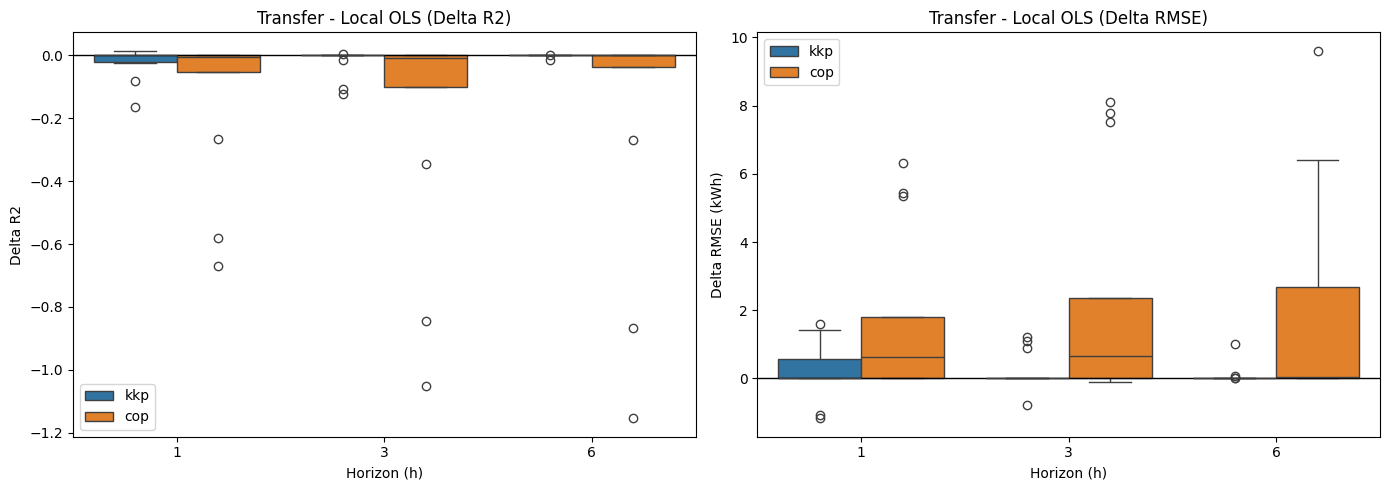

In [13]:
if 'gain' in locals() and len(gain) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    sns.boxplot(data=gain, x='horizon_h', y='delta_r2', hue='source', ax=axes[0])
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_title('Transfer - Local OLS (Delta R2)')
    axes[0].set_xlabel('Horizon (h)')
    axes[0].set_ylabel('Delta R2')

    sns.boxplot(data=gain, x='horizon_h', y='delta_rmse', hue='source', ax=axes[1])
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_title('Transfer - Local OLS (Delta RMSE)')
    axes[1].set_xlabel('Horizon (h)')
    axes[1].set_ylabel('Delta RMSE (kWh)')

    for ax in axes:
        ax.legend(loc='best')

    plt.tight_layout()
    plt.show()


## Reading Guide

Use this notebook output in the thesis as follows:

1. **U06 section**: confirm operational hourly accuracy and identify which baseline is strongest at `1h/3h/6h`.
2. **Portfolio section**: verify if transfer improves mean metrics or only specific buildings/horizons.
3. **Decision point**:
- If transfer improves only sparse/noisy buildings, keep it as a conditional fallback.
- If transfer hurts average performance, keep no-transfer baseline as primary operational model and report transfer as negative/conditional finding.


## Extra Diagnostics: Is Transfer Actually Useful?

These plots make it easier to interpret whether constrained transfer helps meaningfully:
- win-rate by horizon/source
- baseline vs transfer scatter (R2, RMSE)
- per-building delta bars (best/worst)
- U06-focused horizon comparison


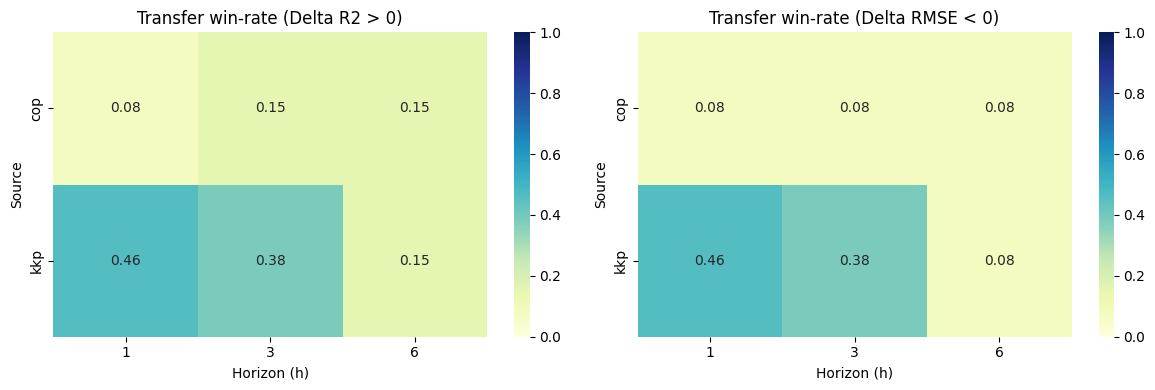

Win-rate table (fraction of buildings where transfer wins):


,horizon_h,source,win_r2,win_rmse
0,1,cop,0.076923,0.076923
2,3,cop,0.153846,0.076923
4,6,cop,0.153846,0.076923
1,1,kkp,0.461538,0.461538
3,3,kkp,0.384615,0.384615
5,6,kkp,0.153846,0.076923


In [14]:
if 'gain' in locals() and len(gain) > 0:
    gain_diag = gain.copy()
    gain_diag['win_r2'] = gain_diag['delta_r2'] > 0
    gain_diag['win_rmse'] = gain_diag['delta_rmse'] < 0

    win_tbl = gain_diag.groupby(['horizon_h', 'source'])[['win_r2', 'win_rmse']].mean().reset_index()

    heat_r2 = win_tbl.pivot(index='source', columns='horizon_h', values='win_r2')
    heat_rmse = win_tbl.pivot(index='source', columns='horizon_h', values='win_rmse')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(heat_r2, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[0])
    axes[0].set_title('Transfer win-rate (Delta R2 > 0)')
    axes[0].set_xlabel('Horizon (h)')
    axes[0].set_ylabel('Source')

    sns.heatmap(heat_rmse, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[1])
    axes[1].set_title('Transfer win-rate (Delta RMSE < 0)')
    axes[1].set_xlabel('Horizon (h)')
    axes[1].set_ylabel('Source')

    plt.tight_layout()
    plt.show()

    print('Win-rate table (fraction of buildings where transfer wins):')
    display(win_tbl.sort_values(['source', 'horizon_h']))


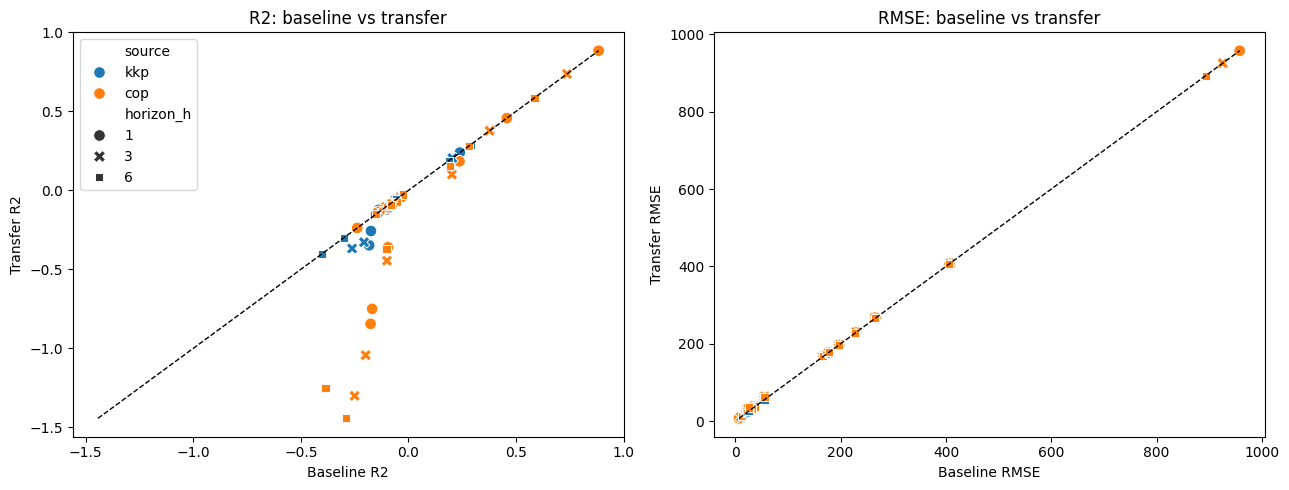

In [15]:
if 'gain' in locals() and len(gain) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # R2 scatter
    sns.scatterplot(
        data=gain,
        x='r2_base',
        y='r2_transfer',
        hue='source',
        style='horizon_h',
        s=70,
        ax=axes[0],
    )
    mn = min(gain['r2_base'].min(), gain['r2_transfer'].min())
    mx = max(gain['r2_base'].max(), gain['r2_transfer'].max())
    axes[0].plot([mn, mx], [mn, mx], 'k--', linewidth=1)
    axes[0].set_title('R2: baseline vs transfer')
    axes[0].set_xlabel('Baseline R2')
    axes[0].set_ylabel('Transfer R2')

    # RMSE scatter
    sns.scatterplot(
        data=gain,
        x='rmse_base',
        y='rmse_transfer',
        hue='source',
        style='horizon_h',
        s=70,
        ax=axes[1],
        legend=False,
    )
    mn2 = min(gain['rmse_base'].min(), gain['rmse_transfer'].min())
    mx2 = max(gain['rmse_base'].max(), gain['rmse_transfer'].max())
    axes[1].plot([mn2, mx2], [mn2, mx2], 'k--', linewidth=1)
    axes[1].set_title('RMSE: baseline vs transfer')
    axes[1].set_xlabel('Baseline RMSE')
    axes[1].set_ylabel('Transfer RMSE')

    plt.tight_layout()
    plt.show()


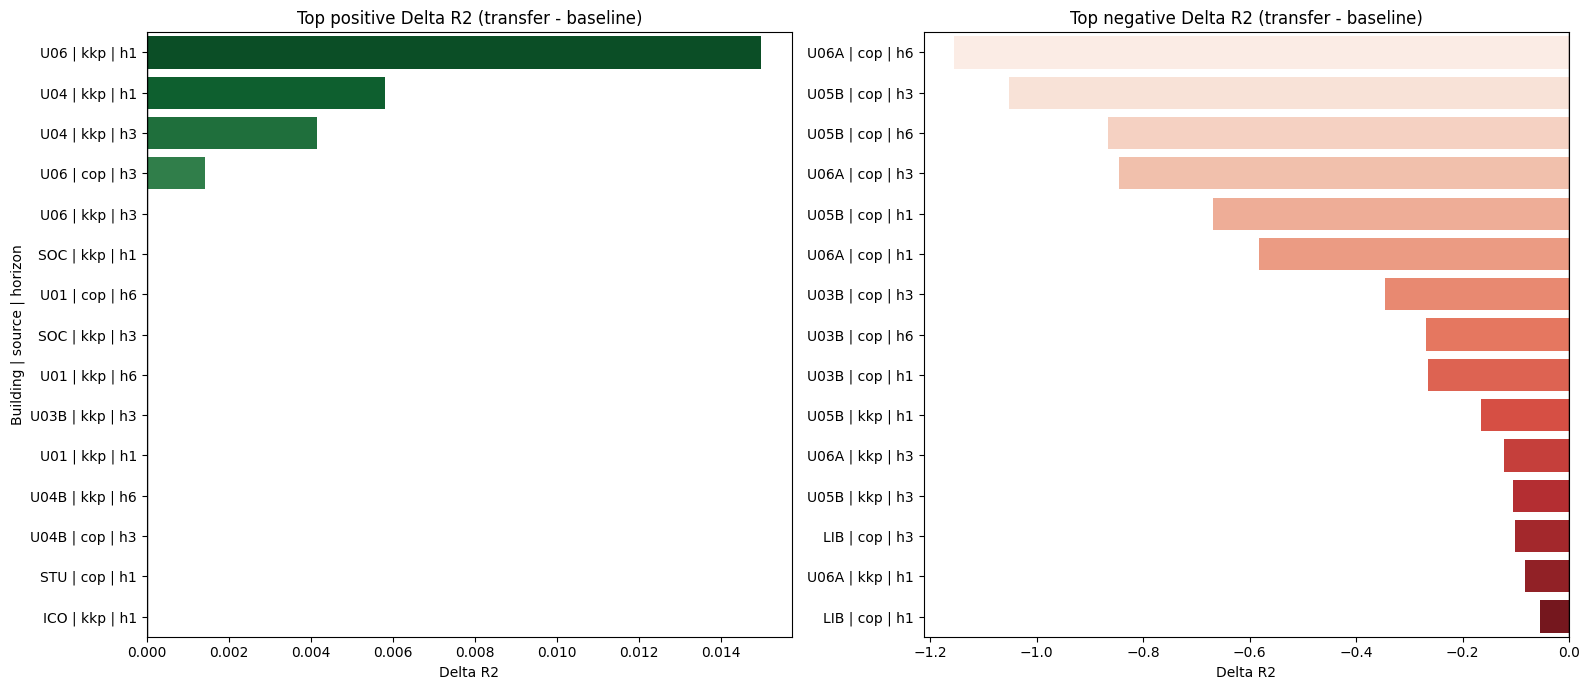

In [16]:
if 'gain' in locals() and len(gain) > 0:
    # Show strongest positive and negative impacts by Delta R2.
    top_pos = gain.sort_values('delta_r2', ascending=False).head(15).copy()
    top_neg = gain.sort_values('delta_r2', ascending=True).head(15).copy()

    top_pos['label'] = top_pos['building'] + ' | ' + top_pos['source'] + ' | h' + top_pos['horizon_h'].astype(str)
    top_neg['label'] = top_neg['building'] + ' | ' + top_neg['source'] + ' | h' + top_neg['horizon_h'].astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    sns.barplot(data=top_pos, y='label', x='delta_r2', palette='Greens_r', ax=axes[0])
    axes[0].axvline(0, color='black', linewidth=1)
    axes[0].set_title('Top positive Delta R2 (transfer - baseline)')
    axes[0].set_xlabel('Delta R2')
    axes[0].set_ylabel('Building | source | horizon')

    sns.barplot(data=top_neg, y='label', x='delta_r2', palette='Reds', ax=axes[1])
    axes[1].axvline(0, color='black', linewidth=1)
    axes[1].set_title('Top negative Delta R2 (transfer - baseline)')
    axes[1].set_xlabel('Delta R2')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()


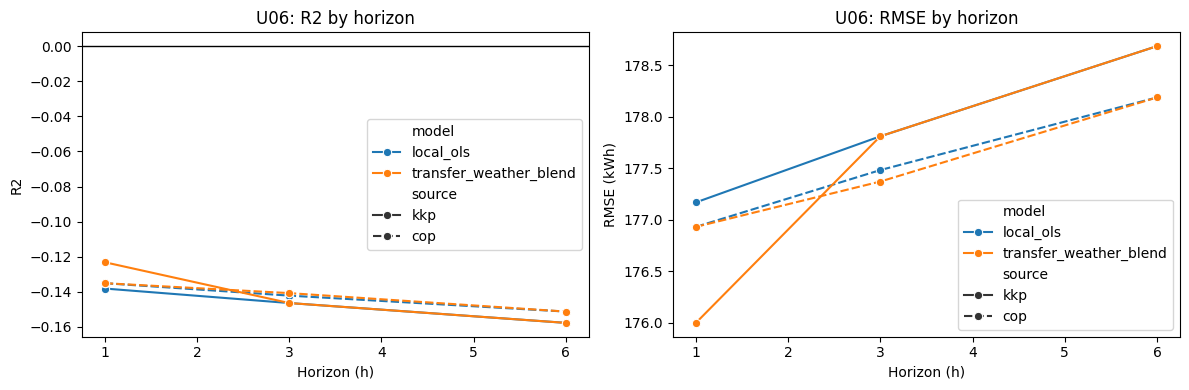

U06 transfer deltas:


,horizon_h,source,r2_base,rmse_base,r2_transfer,rmse_transfer,alpha_weather_local,donors,delta_r2,delta_rmse
1,1,cop,-0.135058,176.929848,-0.135058,176.929848,1.0,"[SOC, U03, U03B]",-2.220446e-16,2.842171e-14
3,3,cop,-0.142142,177.481108,-0.140711,177.369844,0.9,"[SOC, U03, U03B]",1.431582e-03,-1.112639e-01
5,6,cop,-0.151234,178.186107,-0.151234,178.186107,1.0,"[SOC, U03, U03B]",0.000000e+00,0.000000e+00
0,1,kkp,-0.138108,177.167384,-0.123128,175.997566,0.0,"[SOC, U03, U03B]",1.498000e-02,-1.169818e+00
2,3,kkp,-0.146367,177.809080,-0.146367,177.809080,1.0,"[SOC, U03, U03B]",6.661338e-16,-2.842171e-14
4,6,kkp,-0.157677,178.684005,-0.157677,178.684005,1.0,"[SOC, U03, U03B]",0.000000e+00,0.000000e+00


In [17]:
if 'u06_df' in locals() and len(u06_df) > 0:
    u = u06_df[u06_df['model'].isin(['local_ols', 'transfer_weather_blend'])].copy()
    if len(u) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

        sns.lineplot(data=u, x='horizon_h', y='r2', hue='model', style='source', marker='o', ax=axes[0])
        axes[0].set_title('U06: R2 by horizon')
        axes[0].set_xlabel('Horizon (h)')
        axes[0].set_ylabel('R2')
        axes[0].axhline(0, color='black', linewidth=1)

        sns.lineplot(data=u, x='horizon_h', y='rmse', hue='model', style='source', marker='o', ax=axes[1])
        axes[1].set_title('U06: RMSE by horizon')
        axes[1].set_xlabel('Horizon (h)')
        axes[1].set_ylabel('RMSE (kWh)')

        plt.tight_layout()
        plt.show()

        print('U06 transfer deltas:')
        uu_base = u06_df[u06_df['model']=='local_ols'][['horizon_h','source','r2','rmse']].rename(columns={'r2':'r2_base','rmse':'rmse_base'})
        uu_tr = u06_df[u06_df['model']=='transfer_weather_blend'][['horizon_h','source','r2','rmse','alpha_weather_local','donors']].rename(columns={'r2':'r2_transfer','rmse':'rmse_transfer'})
        uu = uu_base.merge(uu_tr, on=['horizon_h','source'], how='inner')
        uu['delta_r2'] = uu['r2_transfer'] - uu['r2_base']
        uu['delta_rmse'] = uu['rmse_transfer'] - uu['rmse_base']
        display(uu.sort_values(['source','horizon_h']))
